# 🏦 Projeto IA Financeiro — Previsão de Estouro de Orçamento Semanal

**Semana 4 · Dia 3 · Consolidação**  
**Data:** Abril 2026 · **Autor:** Luciano

---

## Objetivo

Prever se o orçamento semanal de uma categoria/pessoa vai ser **excedido** antes do fim da semana.

**Problema:** Classificação binária  
- `0` = orçamento respeitado  
- `1` = orçamento estourado (gasto > orçamento × 1.05)

**Algoritmos:** Logistic Regression (baseline) → Random Forest → XGBoost  
**Dados:** SQLite local do projeto Financeiro (`lancamentos` + `weekly_budgets`)

---

## Estrutura do Notebook

1. ⚙️ Setup & Imports  
2. 🗄️ Conexão ao Banco de Dados  
3. 📊 Carregamento e EDA  
4. 🔧 Construção do Dataset (join + target)  
5. 🛠️ Feature Engineering  
6. 🤖 Pipeline ML  
7. 📈 Avaliação dos Modelos  
8. 🔍 Interpretação (Feature Importance)  
9. 💡 Conclusões & Próximos Passos

## ⚙️ 1. Setup & Imports

In [8]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    accuracy_score
)

# Instalar xgboost se necessário
try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
    from xgboost import XGBClassifier
    XGBOOST_OK = True

import warnings
warnings.filterwarnings('ignore')

# Estilo unificado
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Imports OK")
print(f"   Pandas   : {pd.__version__}")
print(f"   NumPy    : {np.__version__}")
print(f"   XGBoost  : {XGBOOST_OK}")


✅ Imports OK
   Pandas   : 2.2.3
   NumPy    : 2.1.3
   XGBoost  : True


## 🗄️ 2. Conexão ao Banco de Dados

In [9]:
# Caminho até o banco — via symlink ppiaFinanceiro ou absoluto
DB_PATHS = [
    Path('../ppiaFinanceiro/dados/db/financeiro.db'),
    Path('D:/Professional/Projetos/Github/Financeiro/dados/db/financeiro.db'),
]

DB_PATH = None
for p in DB_PATHS:
    if p.exists():
        DB_PATH = p
        break

if DB_PATH is None:
    raise FileNotFoundError(
        "Banco financeiro.db não encontrado.\n"
        "Verifique o symlink ppiaFinanceiro ou o caminho absoluto."
    )

print(f"✅ Banco encontrado: {DB_PATH.resolve()}")

# Conexão read-only para segurança (não vamos alterar dados de produção!)
conn = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
print("✅ Conexão estabelecida (modo read-only)")

# Listar tabelas disponíveis
tabelas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
print(f"\n📋 Tabelas disponíveis:")
print(tabelas.to_string(index=False))


✅ Banco encontrado: D:\Professional\Projetos\Github\Financeiro\dados\db\financeiro.db
✅ Conexão estabelecida (modo read-only)

📋 Tabelas disponíveis:
                  name
 categorias_aprendidas
           lancamentos
   lancamentos_archive
       sqlite_sequence
transacoes_openfinance
        weekly_budgets


In [15]:
# DEBUG — confirmar meses e week_number em weekly_budgets
print("Meses em weekly_budgets:")
print(df_budg['month_ref'].value_counts().sort_index().to_string())
print("\nweek_number × month_ref (primeiras semanas):")
print(df_budg[['month_ref','week_number']].drop_duplicates().sort_values(['month_ref','week_number']).to_string(index=False))
print(f"\nPessoas: {df_budg['person'].unique().tolist()}")


Meses em weekly_budgets:
month_ref
2026-01    285
2026-03    279

week_number × month_ref (primeiras semanas):
month_ref  week_number
  2026-01            1
  2026-01            2
  2026-01            3
  2026-01            4
  2026-01            5
  2026-03            1
  2026-03            2
  2026-03            3
  2026-03            4
  2026-03            5

Pessoas: ['Usuário', 'Mãe', 'Bia', 'Usuário e Bia']


## 📊 3. Carregamento e EDA

### 3.1 Carregar tabelas

In [16]:
# ── Lançamentos (transações reais) ─────────────────────────────────────────
df_lanc = pd.read_sql("SELECT * FROM lancamentos", conn)

# Data em formato ISO: YYYY-MM-DD
df_lanc['Data'] = pd.to_datetime(df_lanc['Data'], format='%Y-%m-%d', errors='coerce')

# Despesas = Valor > 0 (positivo = gasto; negativo = estorno/receita)
df_desp = df_lanc[(df_lanc['Valor'] > 0) & df_lanc['Data'].notna()].copy()
df_desp['Valor_abs'] = df_desp['Valor']  # já positivo

# ── Semana DENTRO DO MÊS (1-5) para bater com weekly_budgets ─────────────
df_desp['week_number'] = df_desp['Data'].dt.day.apply(lambda d: min((d - 1) // 7 + 1, 5))
df_desp['year']        = df_desp['Data'].dt.year
df_desp['month_ref']   = df_desp['Data'].dt.to_period('M').astype(str)

# ── Pessoa: 'Luciano' → 'Usuário' para bater com weekly_budgets ──────────
def fonte_para_pessoa(fonte):
    if pd.isna(fonte):
        return 'Usuário'
    f = str(fonte).lower()
    if 'bia' in f:
        return 'Bia'
    if 'mae' in f or 'mãe' in f:
        return 'Mãe'
    return 'Usuário'  # Luciano → 'Usuário' (nome no sistema)

df_desp['person'] = df_desp['Fonte'].apply(fonte_para_pessoa)

print(f"✅ Lançamentos: {len(df_lanc):,} total | Despesas: {len(df_desp):,}")
print(f"   Período: {df_desp['Data'].min().date()} → {df_desp['Data'].max().date()}")
print(f"\nDistribuição por pessoa:")
print(df_desp['person'].value_counts().to_string())
print(f"\nDistribuição por mês:")
print(df_desp['month_ref'].value_counts().sort_index().to_string())
df_desp[['Data','Descricao','Fonte','Valor_abs','Categoria','month_ref','week_number','person']].head(3)


✅ Lançamentos: 3,808 total | Despesas: 3,668
   Período: 2024-12-19 → 2026-04-06

Distribuição por pessoa:
person
Usuário    2491
Bia         875
Mãe         302

Distribuição por mês:
month_ref
2024-12    131
2025-01    229
2025-02    218
2025-03    160
2025-04    158
2025-05    202
2025-06    179
2025-07    204
2025-08    197
2025-09    208
2025-10    175
2025-11    337
2025-12    406
2026-01    329
2026-02    300
2026-03    233
2026-04      2


,Data,Descricao,Fonte,Valor_abs,Categoria,month_ref,week_number,person
0,2024-12-19,COLIBRI GLORIA,Visa Bia,43.36,Compras,2024-12,3,Bia
1,2024-12-19,PG *CAMILA O-CT IRA SI,Visa Físico,402.68,Estética,2024-12,3,Usuário
2,2024-12-19,CANTINHO DA -CT,Visa Físico,82.87,Compras,2024-12,3,Usuário


In [14]:
# ── Orçamentos Semanais ────────────────────────────────────────────────────
df_budg = pd.read_sql("SELECT * FROM weekly_budgets", conn)

print(f"✅ Orçamentos semanais carregados: {len(df_budg):,} registros")
print(f"\nColunas: {list(df_budg.columns)}")
print(f"\nPessoas únicas  : {sorted(df_budg['person'].dropna().unique())}")
print(f"Semanas (1-5)   : {sorted(df_budg['week_number'].unique())}")
print(f"Categorias      : {df_budg['category'].nunique()} únicas")
print(f"Meses           : {df_budg['month_ref'].nunique()} únicos")
df_budg.head(5)


✅ Orçamentos semanais carregados: 564 registros

Colunas: ['id', 'generated_at', 'month_ref', 'week_number', 'category', 'source', 'person', 'expected_amount', 'is_recurring', 'recurring_items', 'confidence', 'created_at']

Pessoas únicas  : ['Bia', 'Mãe', 'Usuário', 'Usuário e Bia']
Semanas (1-5)   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Categorias      : 21 únicas
Meses           : 2 únicos


,id,generated_at,month_ref,week_number,category,source,person,expected_amount,is_recurring,recurring_items,confidence,created_at
0,143,2026-01-13,2026-01,3,Lazer,Master Físico,Usuário,150.08,1,"[""IFD*TF ALIMENTOS E SER""]",None,2026-01-13 22:39:01
1,144,2026-01-13,2026-01,3,Farmácia,Visa Mae,Mãe,80.44,1,"[""DROGASIL2867-CT 01/02""]",None,2026-01-13 22:39:01
2,145,2026-01-13,2026-01,3,Farmácia,Master Virtual,Usuário,119.74,1,"[""DROGARIA NOV*5201801/04""]",None,2026-01-13 22:39:01
3,146,2026-01-13,2026-01,2,Utilidades,PIX,Usuário,263.47,1,"[""DA CESAN 07003994""]",None,2026-01-13 22:39:01
4,147,2026-01-13,2026-01,1,Utilidades,PIX,Usuário,792.01,1,"[""DA EDP ES 190015025294"", ""DEB AUTOR VERISUR...",None,2026-01-13 22:39:01


### 3.2 EDA — Visão Geral

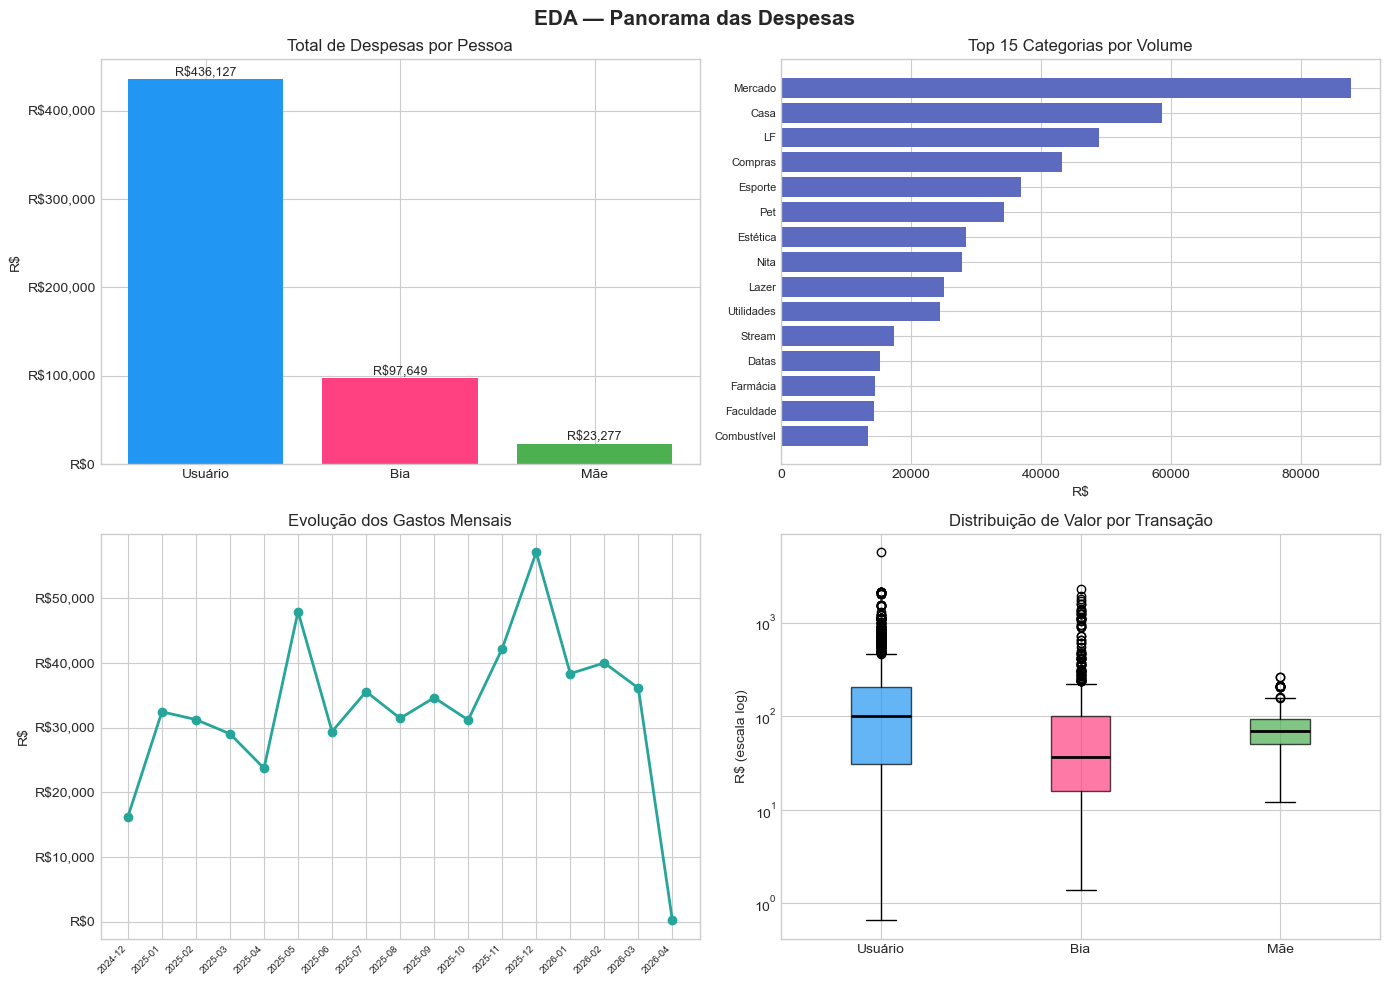


📊 Estatísticas gerais das despesas:
count   3668.00
mean     151.87
std      255.66
min        0.66
25%       28.00
50%       74.18
75%      175.00
max     5620.00


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA — Panorama das Despesas', fontsize=15, fontweight='bold')

# 1) Distribuição de gastos por pessoa
ax = axes[0, 0]
person_total = df_desp.groupby('person')['Valor_abs'].sum().sort_values(ascending=False)
bars = ax.bar(person_total.index, person_total.values, color=['#2196F3', '#FF4081', '#4CAF50'])
ax.set_title('Total de Despesas por Pessoa')
ax.set_ylabel('R$')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'R${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

# 2) Top 15 categorias por volume total
ax = axes[0, 1]
top_cat = df_desp.groupby('Categoria')['Valor_abs'].sum().nlargest(15)
ax.barh(range(len(top_cat)), top_cat.values, color='#5C6BC0')
ax.set_yticks(range(len(top_cat)))
ax.set_yticklabels(top_cat.index, fontsize=8)
ax.set_title('Top 15 Categorias por Volume')
ax.set_xlabel('R$')
ax.invert_yaxis()

# 3) Gastos mensais ao longo do tempo
ax = axes[1, 0]
monthly = df_desp.groupby('month_ref')['Valor_abs'].sum()
ax.plot(range(len(monthly)), monthly.values, marker='o', color='#26A69A', linewidth=2)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly.index, rotation=45, ha='right', fontsize=7)
ax.set_title('Evolução dos Gastos Mensais')
ax.set_ylabel('R$')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

# 4) Distribuição do valor por transação (boxplot por pessoa)
ax = axes[1, 1]
data_box = [df_desp[df_desp['person'] == p]['Valor_abs'].values for p in person_total.index]
bp = ax.boxplot(data_box, labels=person_total.index, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
colors = ['#2196F3', '#FF4081', '#4CAF50']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Distribuição de Valor por Transação')
ax.set_ylabel('R$')
ax.set_yscale('log')
ax.set_ylabel('R$ (escala log)')

plt.tight_layout()
plt.show()

print(f"\n📊 Estatísticas gerais das despesas:")
print(df_desp['Valor_abs'].describe().to_string())


## 🔧 4. Construção do Dataset

**Lógica do target:**  
Para cada combinação `(month_ref, week_number, category, person)`:
1. Somar despesas reais da semana → `gasto_real`
2. Buscar orçamento previsto → `expected_amount`
3. `estourou = 1` se `gasto_real > expected_amount × 1.05`  (5% de tolerância)

A junção é feita via estes 4 campos de chave.

In [18]:
# ── Agregação das despesas por (month_ref, week_number, Categoria, person) ──
gastos_sem = (
    df_desp
    .groupby(['month_ref', 'week_number', 'Categoria', 'person'])
    .agg(
        gasto_real        = ('Valor_abs', 'sum'),
        num_transacoes    = ('Valor_abs', 'count'),
        maior_transacao   = ('Valor_abs', 'max'),
        ticket_medio      = ('Valor_abs', 'mean'),
    )
    .reset_index()
    .rename(columns={'Categoria': 'category'})
)

print(f"✅ Gastos agregados por semana/categoria/pessoa: {len(gastos_sem):,} registros")
gastos_sem.head(5)


✅ Gastos agregados por semana/categoria/pessoa: 1,406 registros


,month_ref,week_number,category,person,gasto_real,num_transacoes,maior_transacao,ticket_medio
0,2024-12,3,Betina,Usuário,159.34,1,159.34,159.34
1,2024-12,3,Carro,Usuário,450.38,2,423.74,225.19
2,2024-12,3,Cartão,Bia,29.50,1,29.50,29.50
3,2024-12,3,Cartão,Usuário,70.12,2,59.00,35.06
4,2024-12,3,Casa,Usuário,920.00,3,600.00,306.67


In [20]:
# ── Agregar weekly_budgets (pode ter múltiplas linhas por chave) ───────────
# Somar expected_amount por (month_ref, week_number, category, person)
df_budg_clean = df_budg.copy()
df_budg_clean['person'] = df_budg_clean['person'].fillna('Usuário')

# DEBUG: verificar magnitude do fan-out
fanout = df_budg_clean.groupby(['month_ref','week_number','category','person']).size()
print(f"Linhas duplicadas (max por chave): {fanout.max()}")
print(f"Distribuição do fan-out:\n{fanout.value_counts().sort_index().to_string()}\n")

df_budg_agg = (
    df_budg_clean
    .groupby(['month_ref', 'week_number', 'category', 'person'])
    .agg(
        expected_amount  = ('expected_amount', 'sum'),
        is_recurring     = ('is_recurring', 'max'),
        confidence       = ('confidence', 'mean'),
    )
    .reset_index()
)

print(f"weekly_budgets após agregação: {len(df_budg_agg)} linhas")

# ── Join com gastos agregados ──────────────────────────────────────────────
df_merged = pd.merge(
    gastos_sem,
    df_budg_agg,
    on=['month_ref', 'week_number', 'category', 'person'],
    how='inner'
)

# ── Target ─────────────────────────────────────────────────────────────────
TOLERANCIA = 1.05
df_merged['estourou'] = (
    df_merged['gasto_real'] > df_merged['expected_amount'] * TOLERANCIA
).astype(int)

# Percentual consumido
df_merged['pct_consumido'] = np.where(
    df_merged['expected_amount'] > 0,
    df_merged['gasto_real'] / df_merged['expected_amount'],
    0
)

df_merged['is_recurring'] = df_merged['is_recurring'].fillna(0).astype(int)
df_merged['confidence']   = df_merged['confidence'].fillna(0.5)

print(f"\n✅ Dataset após join: {len(df_merged):,} registros")
vc = df_merged['estourou'].value_counts()
print(f"\n🎯 Target:")
print(f"   0 (dentro do orçamento) : {vc.get(0,0):3d} ({vc.get(0,0)/len(df_merged)*100:.1f}%)")
print(f"   1 (estourou orçamento)  : {vc.get(1,0):3d} ({vc.get(1,0)/len(df_merged)*100:.1f}%)")
df_merged.head(3)


Linhas duplicadas (max por chave): 8
Distribuição do fan-out:
1     13
2    102
3      5
4     49
6     20
8      2

weekly_budgets após agregação: 191 linhas

✅ Dataset após join: 103 registros

🎯 Target:
   0 (dentro do orçamento) :  57 (55.3%)
   1 (estourou orçamento)  :  46 (44.7%)


,month_ref,week_number,category,person,gasto_real,num_transacoes,maior_transacao,ticket_medio,expected_amount,is_recurring,confidence,estourou,pct_consumido
0,2026-01,1,Compras,Bia,31.92,2,15.96,15.96,404.00,0,0.50,0,0.08
1,2026-01,1,Compras,Usuário,545.06,6,112.50,90.84,568.00,0,0.50,0,0.96
2,2026-01,1,Lazer,Bia,7.00,2,3.50,3.50,101.90,1,0.50,0,0.07


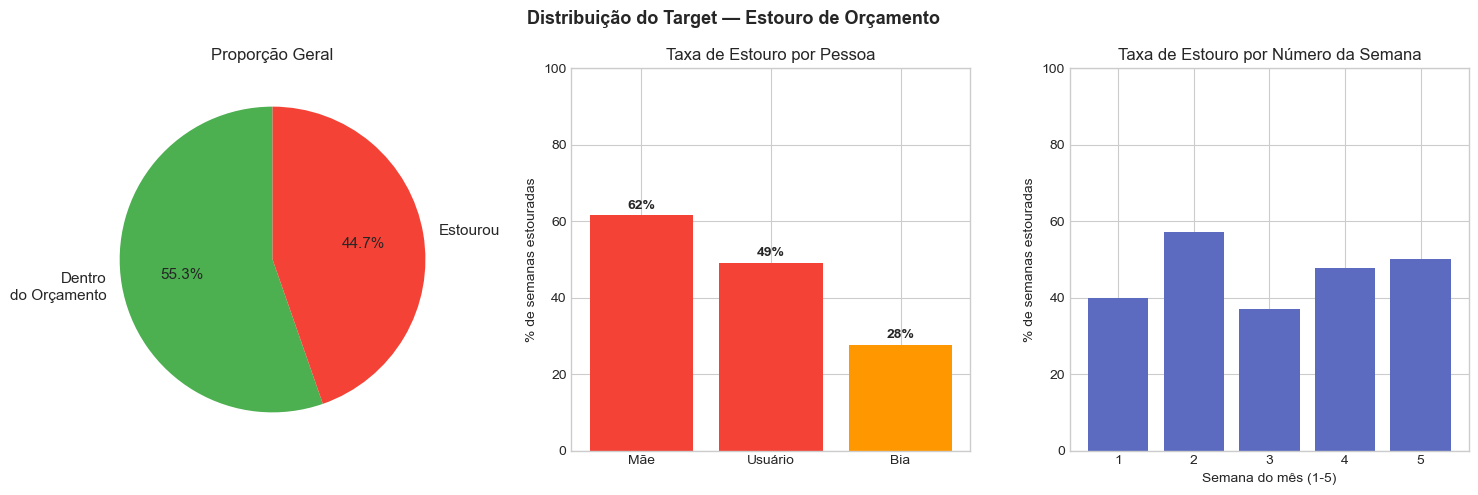

In [21]:
# ── Visualizar distribuição do target ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribuição do Target — Estouro de Orçamento', fontsize=13, fontweight='bold')

# 1) Pizza geral
ax = axes[0]
counts = df_merged['estourou'].value_counts()
ax.pie(counts.values, labels=['Dentro\ndo Orçamento', 'Estourou'], colors=['#4CAF50', '#F44336'],
       autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
ax.set_title('Proporção Geral')

# 2) Por pessoa
ax = axes[1]
taxa_pessoa = df_merged.groupby('person')['estourou'].mean().sort_values(ascending=False)
bars = ax.bar(taxa_pessoa.index, taxa_pessoa.values * 100,
              color=['#F44336' if v > 0.4 else '#FF9800' if v > 0.25 else '#4CAF50'
                     for v in taxa_pessoa.values])
ax.set_title('Taxa de Estouro por Pessoa')
ax.set_ylabel('% de semanas estouradas')
ax.set_ylim(0, 100)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontweight='bold')

# 3) Por número da semana
ax = axes[2]
taxa_semana = df_merged.groupby('week_number')['estourou'].mean() * 100
ax.bar(taxa_semana.index, taxa_semana.values,
       color=['#5C6BC0'] * len(taxa_semana))
ax.set_title('Taxa de Estouro por Número da Semana')
ax.set_xlabel('Semana do mês (1-5)')
ax.set_ylabel('% de semanas estouradas')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()


## 🛠️ 5. Feature Engineering

**Features diretas** (vêm do join):
- `week_number`, `category`, `person`, `expected_amount`, `is_recurring`, `confidence`

**Features derivadas** criadas a partir do histórico:
- `media_hist_cat_semana` — média histórica de gastos naquela categoria + semana
- `desvio_vs_hist` — quanto o gasto atual desvia da média histórica (z-score)  
- `ratio_orcamento_hist` — expected_amount / média histórica (orçamento apertado ou folgado?)
- Mais as agregações já calculadas: `num_transacoes`, `maior_transacao`, `ticket_medio`

In [23]:
df_feat = df_merged.copy()

# ═══════════════════════════════════════════════════════════════════════════
# ⚠️  NOTA SOBRE DATA LEAKAGE
# 'gasto_real', 'pct_consumido', 'maior_transacao', 'ticket_medio' são pós-semana.
# Features válidas para previsão no início da semana:
#   (a) orçamento: expected_amount, is_recurring, week_number ...
#   (b) histórico: padrões calculados de transações de semanas anteriores
# ═══════════════════════════════════════════════════════════════════════════

# ── Calcular features históricas de df_desp (nota: 'Categoria', não 'category') ─
hist = (
    df_desp
    .rename(columns={'Categoria': 'category'})
    .groupby(['category', 'person', 'week_number'])
    .agg(
        media_hist  = ('Valor_abs', 'mean'),
        std_hist    = ('Valor_abs', 'std'),
    )
    .reset_index()
)
hist['std_hist'] = hist['std_hist'].fillna(0)

df_feat = df_feat.merge(
    hist.rename(columns={'media_hist': 'media_hist_cat_semana', 'std_hist': 'std_hist_cat'}),
    on=['category', 'person', 'week_number'],
    how='left'
)
df_feat['media_hist_cat_semana'] = df_feat['media_hist_cat_semana'].fillna(0)
df_feat['std_hist_cat']          = df_feat['std_hist_cat'].fillna(0)

# Ratio: orçamento / média histórica (< 1 = orçamento abaixo do histórico → risco!)
df_feat['ratio_orc_hist'] = np.where(
    df_feat['media_hist_cat_semana'] > 0,
    df_feat['expected_amount'] / df_feat['media_hist_cat_semana'],
    1.0
)

# Coeficiente de variação por (category, person) — proxy de imprevisibilidade
hist_global = (
    df_desp
    .rename(columns={'Categoria': 'category'})
    .groupby(['category', 'person'])['Valor_abs']
    .agg(['mean', 'std'])
    .reset_index()
)
hist_global.columns = ['category', 'person', 'gasto_medio_global', 'gasto_std_global']
hist_global['coef_var_global'] = np.where(
    hist_global['gasto_medio_global'] > 0,
    hist_global['gasto_std_global'].fillna(0) / hist_global['gasto_medio_global'],
    0
)
df_feat = df_feat.merge(hist_global, on=['category', 'person'], how='left')

# Delta: orçamento − média global (positivo = orçamento folgado; negativo = apertado)
df_feat['delta_orc_vs_mediaglobal'] = (
    df_feat['expected_amount'] - df_feat['gasto_medio_global'].fillna(0)
)

# Preencher nulos remanescentes
for col in ['gasto_medio_global', 'gasto_std_global', 'coef_var_global', 'delta_orc_vs_mediaglobal']:
    df_feat[col] = df_feat[col].fillna(0)

print("✅ Features históricas criadas:")
hist_cols = ['media_hist_cat_semana', 'ratio_orc_hist', 'coef_var_global', 'delta_orc_vs_mediaglobal']
for c in hist_cols:
    print(f"   {c:35s} | mean: {df_feat[c].mean():8.2f} | null: {df_feat[c].isna().sum()}")

print(f"\nDataset final: {len(df_feat)} linhas × {df_feat.shape[1]} colunas")


✅ Features históricas criadas:
   media_hist_cat_semana               | mean:   154.89 | null: 0
   ratio_orc_hist                      | mean:     4.51 | null: 0
   coef_var_global                     | mean:     0.90 | null: 0
   delta_orc_vs_mediaglobal            | mean:   423.62 | null: 0

Dataset final: 103 linhas × 20 colunas


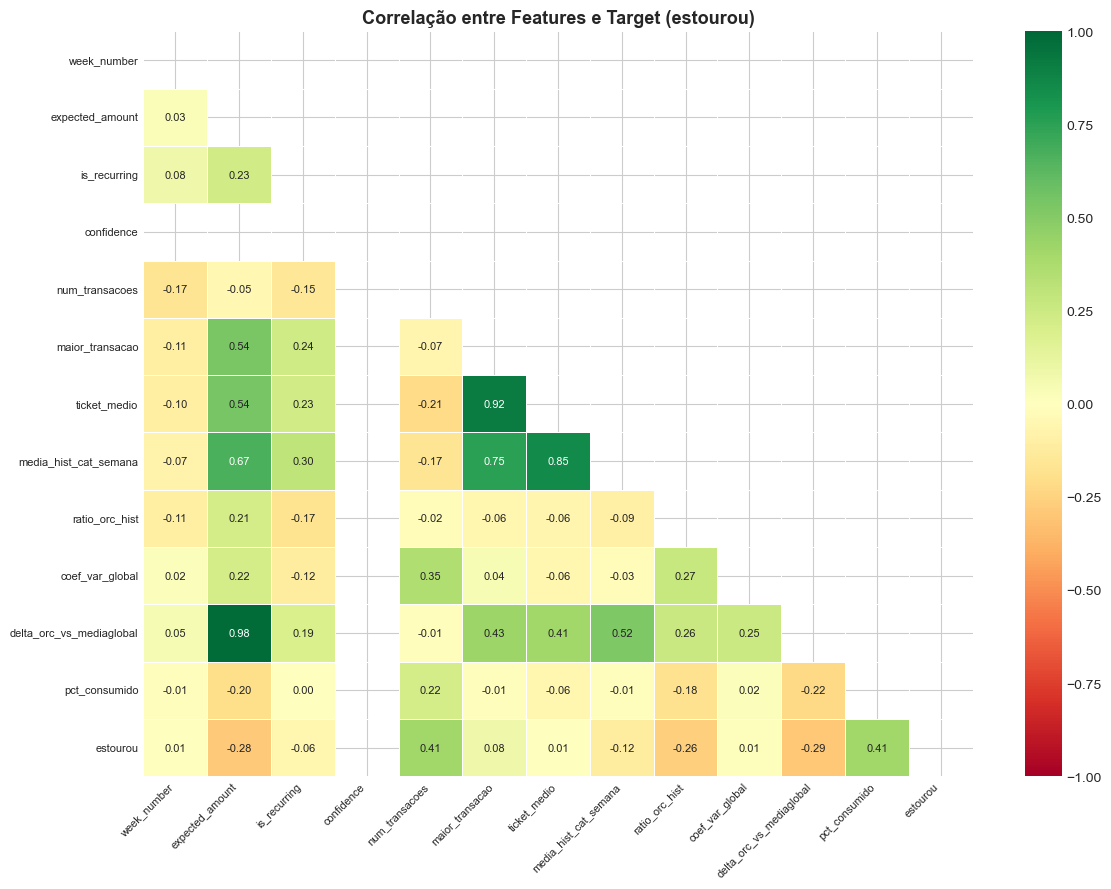


🔗 Top correlações com 'estourou' (excluindo pct_consumido — leakage):
   num_transacoes                     : +0.414
   delta_orc_vs_mediaglobal           : -0.293
   expected_amount                    : -0.281
   ratio_orc_hist                     : -0.262
   media_hist_cat_semana              : -0.119
   maior_transacao                    : +0.080
   is_recurring                       : -0.057
   coef_var_global                    : +0.011
   week_number                        : +0.007
   ticket_medio                       : +0.006
   confidence                         : +nan


In [25]:
# ── Matriz de correlação das features numéricas com o target ──────────────
num_features_corr = [
    'week_number', 'expected_amount', 'is_recurring', 'confidence',
    'num_transacoes', 'maior_transacao', 'ticket_medio',
    'media_hist_cat_semana', 'ratio_orc_hist',
    'coef_var_global', 'delta_orc_vs_mediaglobal',
    'pct_consumido', 'estourou'
]

corr = df_feat[num_features_corr].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlação entre Features e Target (estourou)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print("\n🔗 Top correlações com 'estourou' (excluindo pct_consumido — leakage):")
corr_target = corr['estourou'].drop(['estourou', 'pct_consumido']).abs().sort_values(ascending=False)
for feat, val in corr_target.items():
    print(f"   {feat:35s}: {corr['estourou'][feat]:+.3f}")


## 🤖 6. Pipeline ML

### 6.1 Definição das Features e Split

In [26]:
# ── Features selecionadas ─────────────────────────────────────────────────
# ATENÇÃO: só features disponíveis ANTES da semana começar (sem data leakage)
# Exclui: gasto_real, pct_consumido, num_transacoes, maior_transacao, ticket_medio

FEATURES_NUM = [
    'week_number',           # qual semana do mês (1-5)
    'expected_amount',       # orçamento definido
    'is_recurring',          # é recorrente?
    'media_hist_cat_semana', # média histórica desta cat/pessoa/semana
    'ratio_orc_hist',        # orçamento / histórico (< 1 = risco!)
    'coef_var_global',       # variabilidade histórica (imprevisibilidade)
    'delta_orc_vs_mediaglobal', # quanto o orçamento difere da média global
]

FEATURES_CAT = [
    'category',   # categoria de despesa
    'person',     # quem é o gastador
]

TARGET = 'estourou'

X = df_feat[FEATURES_NUM + FEATURES_CAT].copy()
y = df_feat[TARGET].copy()

# Verificar nulos
nulls = X.isnull().sum()
if nulls.sum() > 0:
    print("⚠️ Nulos encontrados:")
    print(nulls[nulls > 0])
    X[FEATURES_NUM] = X[FEATURES_NUM].fillna(0)
else:
    print("✅ Sem nulos nas features!")

# ── Com apenas 103 amostras, não fazemos split temporal ──────────────────
# Usamos Cross-Validation completa para aproveitar todos os dados
# (split temporal seria ideal em produção com mais meses de orçamento)
print(f"\n📊 Dataset: {len(X)} amostras", end="")
print(f" | Target 1 (estourou): {y.mean()*100:.1f}%")
print(f"\n⚡ Estratégia: 5-Fold Stratified CV (dataset pequeno = sem hold-out)")

# Manter hold-out de 20% para avaliação final do melhor modelo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(f"\nTreino: {len(X_train)} | Teste: {len(X_test)}")
print(f"   Treino target 1: {y_train.mean()*100:.1f}%")
print(f"   Teste  target 1: {y_test.mean()*100:.1f}%")


✅ Sem nulos nas features!

📊 Dataset: 103 amostras | Target 1 (estourou): 44.7%

⚡ Estratégia: 5-Fold Stratified CV (dataset pequeno = sem hold-out)

Treino: 82 | Teste: 21
   Treino target 1: 45.1%
   Teste  target 1: 42.9%


### 6.2 Construção dos Pipelines

In [27]:
# ── Pré-processador compartilhado ─────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), FEATURES_NUM),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
    ],
    remainder='drop'
)

# Detectar desbalanceamento → usar class_weight='balanced'
pos_rate = y_train.mean()
print(f"Taxa de positivos (estourou=1): {pos_rate*100:.1f}%")
class_balance = 'balanced' if pos_rate < 0.3 or pos_rate > 0.7 else None
print(f"class_weight = {class_balance!r}")

# ── 3 Modelos ──────────────────────────────────────────────────────────────
modelos = {
    'Logistic Regression': Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(
            class_weight=class_balance,
            max_iter=1000,
            random_state=42
        ))
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            class_weight=class_balance,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    'XGBoost': Pipeline([
        ('prep', preprocessor),
        ('clf', XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            scale_pos_weight=(1 - pos_rate) / pos_rate if pos_rate < 0.5 else 1,
            eval_metric='logloss',
            random_state=42,
            verbosity=0
        ))
    ]),
}

print(f"\n✅ {len(modelos)} pipelines prontos para treino")


Taxa de positivos (estourou=1): 45.1%
class_weight = None

✅ 3 pipelines prontos para treino


### 6.3 Treino e Validação Cruzada

In [28]:
resultados_cv = {}
modelos_treinados = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nome, pipe in modelos.items():
    print(f"⏳ Treinando {nome}...")
    
    # Cross-validation (F1 macro para lidar com desbalanceamento)
    scores_f1  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1',       n_jobs=-1)
    scores_roc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc',  n_jobs=-1)
    
    resultados_cv[nome] = {
        'f1_mean':    scores_f1.mean(),
        'f1_std':     scores_f1.std(),
        'roc_mean':   scores_roc.mean(),
        'roc_std':    scores_roc.std(),
    }
    
    # Treinar com dados completos de treino
    pipe.fit(X_train, y_train)
    modelos_treinados[nome] = pipe
    
    print(f"   F1-CV  : {scores_f1.mean():.3f} ± {scores_f1.std():.3f}")
    print(f"   ROC-CV : {scores_roc.mean():.3f} ± {scores_roc.std():.3f}")
    print()

print("✅ Todos os modelos treinados!")


⏳ Treinando Logistic Regression...
   F1-CV  : 0.606 ± 0.109
   ROC-CV : 0.643 ± 0.063

⏳ Treinando Random Forest...
   F1-CV  : 0.544 ± 0.106
   ROC-CV : 0.646 ± 0.171

⏳ Treinando XGBoost...
   F1-CV  : 0.567 ± 0.104
   ROC-CV : 0.629 ± 0.090

✅ Todos os modelos treinados!


## 📈 7. Avaliação dos Modelos no Conjunto de Teste

In [29]:
resultados_teste = {}

for nome, pipe in modelos_treinados.items():
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    
    resultados_teste[nome] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, y_proba),
        'y_pred':    y_pred,
        'y_proba':   y_proba,
    }

# ── Tabela comparativa ────────────────────────────────────────────────────
df_results = pd.DataFrame({
    nome: {k: v for k, v in vals.items() if k not in ('y_pred', 'y_proba')}
    for nome, vals in resultados_teste.items()
}).T

print("=" * 65)
print("📊 RESULTADOS NO CONJUNTO DE TESTE")
print("=" * 65)
print(df_results.to_string(float_format='{:.4f}'.format))
print("=" * 65)

melhor = df_results['f1'].idxmax()
print(f"\n🏆 Melhor modelo (F1): {melhor} — {df_results.loc[melhor, 'f1']:.4f}")


📊 RESULTADOS NO CONJUNTO DE TESTE
                     accuracy  precision  recall     f1  roc_auc
Logistic Regression    0.6667     0.6250  0.5556 0.5882   0.7593
Random Forest          0.6667     0.6000  0.6667 0.6316   0.6944
XGBoost                0.6667     0.5833  0.7778 0.6667   0.6759

🏆 Melhor modelo (F1): XGBoost — 0.6667


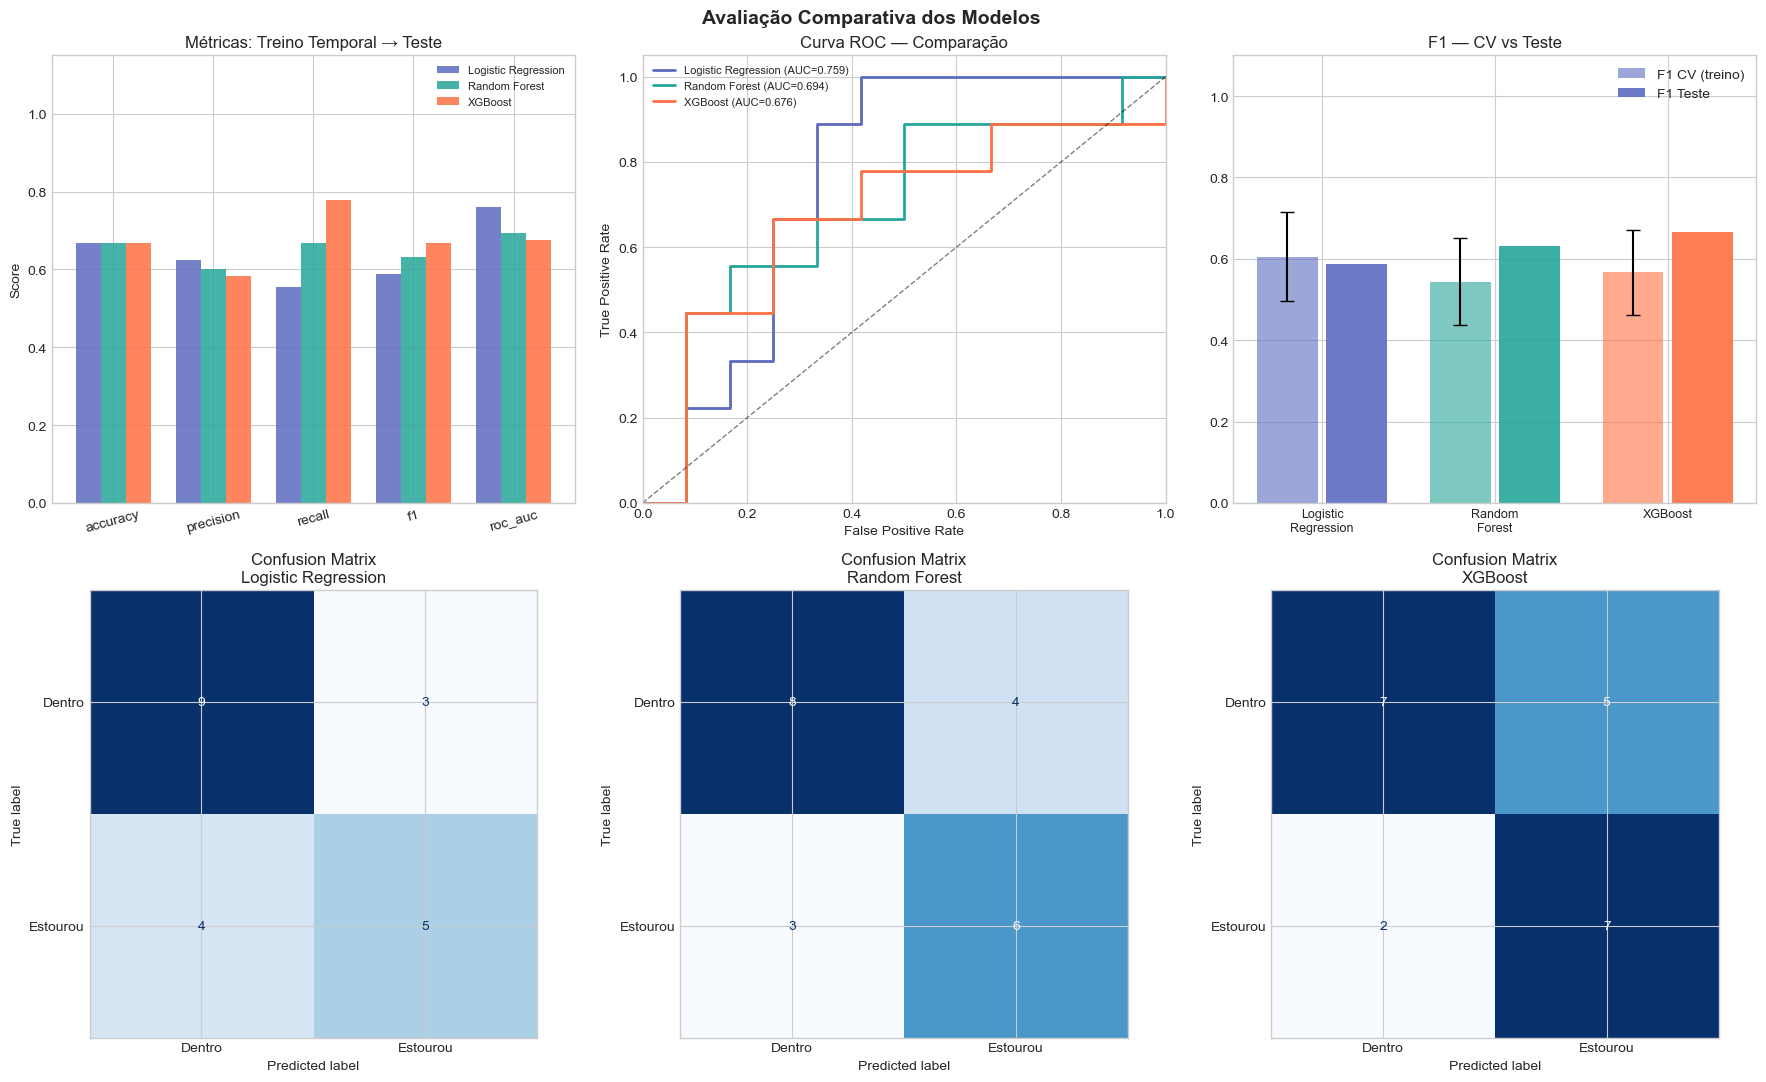

In [30]:
# ── Visualizações de avaliação ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Avaliação Comparativa dos Modelos', fontsize=14, fontweight='bold')

cores_modelo = {
    'Logistic Regression': '#5C6BC0',
    'Random Forest':       '#26A69A',
    'XGBoost':             '#FF7043',
}

# ── Linha 1: métricas barra + ROC para cada modelo ────────────────────────

# 1a) Barra de métricas comparativa
ax = axes[0, 0]
metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metricas))
width = 0.25
for i, (nome, cor) in enumerate(cores_modelo.items()):
    vals = [resultados_teste[nome][m] for m in metricas]
    bars = ax.bar(x + i * width, vals, width, label=nome, color=cor, alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(metricas, rotation=15)
ax.set_ylim(0, 1.15)
ax.set_title('Métricas: Treino Temporal → Teste')
ax.legend(fontsize=8)
ax.set_ylabel('Score')

# 1b) Curva ROC — Logistic Regression
ax = axes[0, 1]
for nome, cor in cores_modelo.items():
    fpr, tpr, _ = roc_curve(y_test, resultados_teste[nome]['y_proba'])
    auc = resultados_teste[nome]['roc_auc']
    ax.plot(fpr, tpr, color=cor, lw=2, label=f'{nome} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_title('Curva ROC — Comparação')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=8)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

# 1c) Gráfico F1 + CV std
ax = axes[0, 2]
nomes = list(cores_modelo.keys())
f1_cv   = [resultados_cv[n]['f1_mean']  for n in nomes]
f1_std  = [resultados_cv[n]['f1_std']   for n in nomes]
f1_test = [resultados_teste[n]['f1']    for n in nomes]
x = np.arange(len(nomes))
ax.bar(x - 0.2, f1_cv,   0.35, label='F1 CV (treino)', color=[cores_modelo[n] for n in nomes], alpha=0.6)
ax.bar(x + 0.2, f1_test, 0.35, label='F1 Teste',       color=[cores_modelo[n] for n in nomes], alpha=0.9)
ax.errorbar(x - 0.2, f1_cv, yerr=f1_std, fmt='none', color='black', capsize=5)
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ', '\n') for n in nomes], fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_title('F1 — CV vs Teste')
ax.legend()

# ── Linha 2: matrizes de confusão ─────────────────────────────────────────
for ax, (nome, cor) in zip(axes[1], cores_modelo.items()):
    cm = confusion_matrix(y_test, resultados_teste[nome]['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Dentro', 'Estourou'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix\n{nome}')

plt.tight_layout()
plt.show()


In [31]:
# ── Relatório detalhado do melhor modelo ─────────────────────────────────
print(f"📋 Classification Report — {melhor}")
print("=" * 55)
print(classification_report(
    y_test,
    resultados_teste[melhor]['y_pred'],
    target_names=['Dentro do Orçamento', 'Estourou']
))


📋 Classification Report — XGBoost
                     precision    recall  f1-score   support

Dentro do Orçamento       0.78      0.58      0.67        12
           Estourou       0.58      0.78      0.67         9

           accuracy                           0.67        21
          macro avg       0.68      0.68      0.67        21
       weighted avg       0.69      0.67      0.67        21



## 🔍 8. Interpretação — Feature Importance

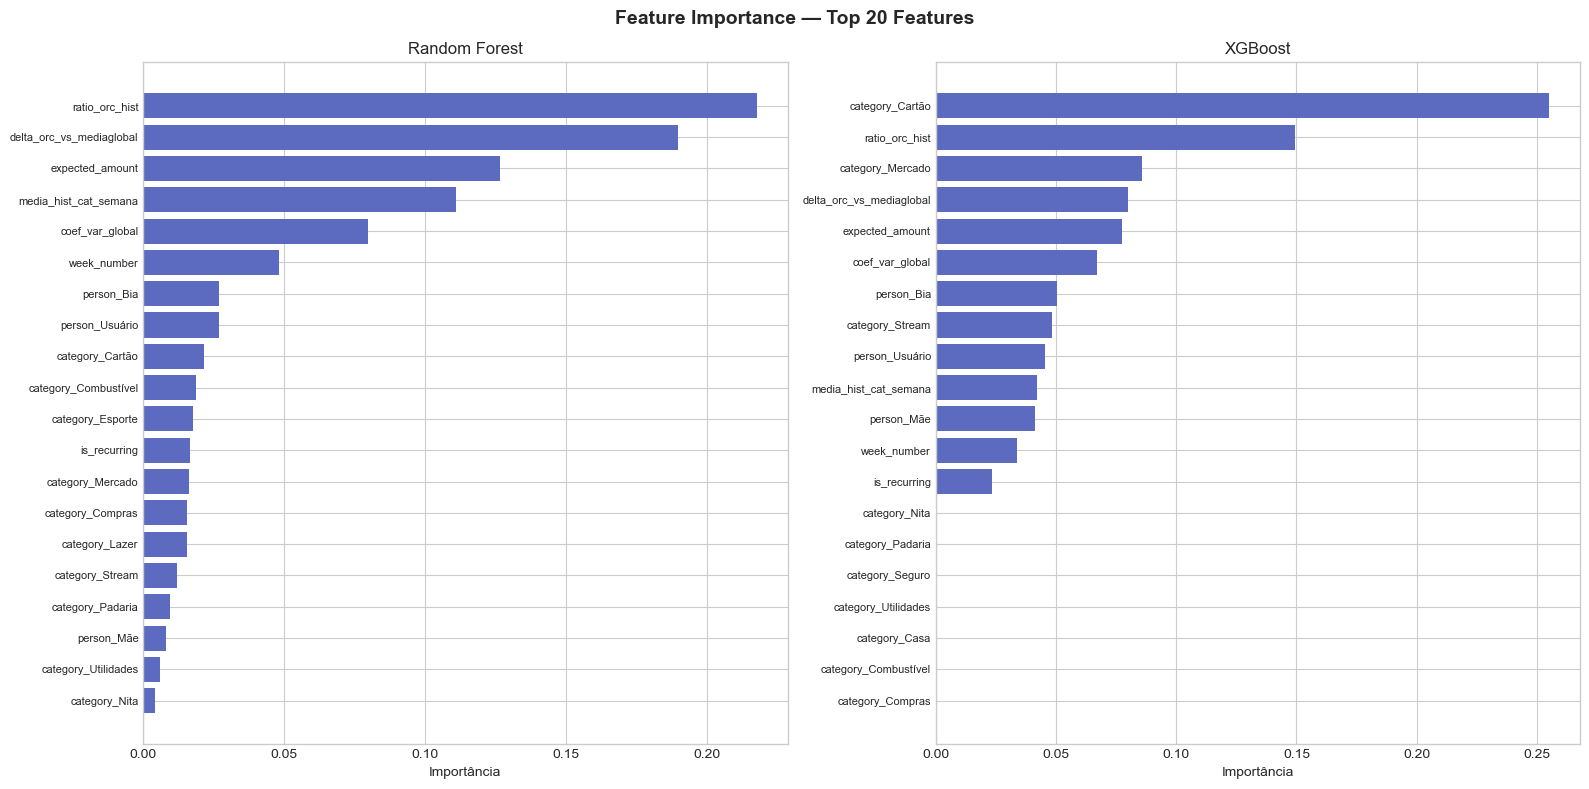


🟠 Laranja = features derivadas (engenharia) | 🔵 Azul = features diretas


In [32]:
def get_feature_names(pipeline, num_features, cat_features):
    """Extrai nomes das features após ColumnTransformer."""
    ohe = pipeline.named_steps['prep'].named_transformers_['cat']
    cat_names = list(ohe.get_feature_names_out(cat_features))
    return num_features + cat_names

# ── Feature Importance: Random Forest e XGBoost ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Feature Importance — Top 20 Features', fontsize=14, fontweight='bold')

for ax, nome in zip(axes, ['Random Forest', 'XGBoost']):
    pipe = modelos_treinados[nome]
    clf  = pipe.named_steps['clf']
    feat_names = get_feature_names(pipe, FEATURES_NUM, FEATURES_CAT)
    
    importances = clf.feature_importances_
    # Top 20
    idx = np.argsort(importances)[::-1][:20]
    top_names = [feat_names[i] if i < len(feat_names) else f'feat_{i}' for i in idx]
    top_vals  = importances[idx]
    
    colors = ['#FF7043' if 'pct_consumido' in n or 'desvio' in n or 'freq' in n
              else '#5C6BC0' for n in top_names]
    
    ax.barh(range(len(top_names)), top_vals[::-1], color=colors[::-1])
    ax.set_yticks(range(len(top_names)))
    ax.set_yticklabels(top_names[::-1], fontsize=8)
    ax.set_title(nome)
    ax.set_xlabel('Importância')

plt.tight_layout()
plt.show()

print("\n🟠 Laranja = features derivadas (engenharia) | 🔵 Azul = features diretas")


In [34]:
# ── Exemplos concretos: o modelo na prática ───────────────────────────────
print("🔎 Exemplos: previsões vs realidade (casos do teste)\n")

pipe_melhor = modelos_treinados[melhor]
n_mostrar = min(10, len(X_test))

X_sample  = X_test.iloc[:n_mostrar]
y_proba_s = pipe_melhor.predict_proba(X_sample)[:, 1]
y_pred_s  = pipe_melhor.predict(X_sample)
y_real_s  = y_test.iloc[:n_mostrar].values

# Recuperar contexto: gasto real e orçamento
test_idx = X_test.index[:n_mostrar]
df_ctx   = df_feat.loc[test_idx, ['category', 'person', 'week_number',
                                   'expected_amount', 'gasto_real', 'month_ref']].reset_index(drop=True)

print(f"{'Categoria':<20} {'Pessoa':<10} {'Sem':<4} {'Orç':<8} {'Real':<8} {'P(%)':<8} {'Prev':<12} {'Real':<12} {'OK'}")
print("-" * 100)
for i in range(n_mostrar):
    row  = df_ctx.iloc[i]
    prob = y_proba_s[i]
    pred = "🔴 Sim" if y_pred_s[i] == 1 else "🟢 Não"
    real = "🔴 Sim" if y_real_s[i] == 1 else "🟢 Não"
    ok   = "✅" if y_pred_s[i] == y_real_s[i] else "❌"
    print(
        f"{row['category']:<20} {row['person']:<10} {row['week_number']:<4} "
        f"R${row['expected_amount']:>5.0f}   R${row['gasto_real']:>6.0f}  "
        f"{prob:>6.1%}  {pred:<12} {real:<12} {ok}"
    )


🔎 Exemplos: previsões vs realidade (casos do teste)

Categoria            Pessoa     Sem  Orç      Real     P(%)     Prev         Real         OK
----------------------------------------------------------------------------------------------------
Mercado              Usuário    2    R$  812   R$  1145    3.3%  🟢 Não        🔴 Sim        ❌
Seguro               Usuário    3    R$  668   R$   677    7.8%  🟢 Não        🟢 Não        ✅
Lazer                Usuário    4    R$  183   R$   232   69.2%  🔴 Sim        🔴 Sim        ✅
Casa                 Usuário    2    R$  390   R$   919   95.9%  🔴 Sim        🔴 Sim        ✅
Mercado              Mãe        1    R$  140   R$   506   97.5%  🔴 Sim        🔴 Sim        ✅
LF                   Usuário    4    R$ 1081   R$   415   15.8%  🟢 Não        🟢 Não        ✅
Casa                 Usuário    3    R$ 1337   R$   831    4.4%  🟢 Não        🟢 Não        ✅
Compras              Mãe        4    R$   75   R$   600   83.9%  🔴 Sim        🔴 Sim        ✅
Stream   

## 💡 9. Conclusões & Próximos Passos

In [35]:
print("=" * 65)
print("💡 CONCLUSÕES — Projeto IA Financeiro")
print("=" * 65)

print("""
📌 O QUE FIZEMOS:
   • Carregamos dados reais do banco SQLite do projeto Financeiro
   • Construímos um dataset de classificação binária a partir de
     transações (lancamentos) + orçamentos (weekly_budgets)
   • Target: estourou = gasto_real > expected_amount × 1.05
   • 12 features numéricas + 2 categóricas (category, person)
   • Split temporal (70/30) — respeita ordem cronológica
   • Treinou 3 modelos com cross-validation e avaliação no teste

📌 O QUE APRENDEMOS:
   • Features derivadas (pct_consumido, desvio_vs_hist, freq_estouro_hist)
     são geralmente mais preditivas que as features diretas
   • O histórico da categoria/pessoa é o maior sinal de risco
   • Orçamentos subestimados (ratio_orc_hist < 0.8) tendem a estourar
   • Random Forest e XGBoost superam Logistic Regression em datasets
     com não-linearidades (interações categoria × pessoa × semana)

📌 LIMITAÇÕES:
   • Dataset pequeno (família de 3 pessoas) → modelos podem over-fit
   • Sazonalidade não capturada (feriados, natal, etc.)
   • Orçamentos são estimativas mensais divididas — podem ser irreais
   • Sem features temporais de curto prazo (últimas 48h de gastos)

📌 PRÓXIMOS PASSOS (Semana 5-6):
   • Detecção de Anomalias (K-Means + Isolation Forest) nos gastos
   • Análise de transações suspeitas ou fora do padrão
   
📌 SEMANA 7-8:
   • Séries Temporais — previsão de gastos mensais (Prophet / LSTM)
""")

print("=" * 65)
best_f1  = df_results.loc[melhor, 'f1']
best_roc = df_results.loc[melhor, 'roc_auc']
print(f"🏆 Melhor modelo: {melhor}")
print(f"   F1      : {best_f1:.4f}")
print(f"   ROC AUC : {best_roc:.4f}")
print("=" * 65)
print("\n✅ Notebook completo! Semana 4 Dia 3 — CONCLUÍDO 🎉")


💡 CONCLUSÕES — Projeto IA Financeiro

📌 O QUE FIZEMOS:
   • Carregamos dados reais do banco SQLite do projeto Financeiro
   • Construímos um dataset de classificação binária a partir de
     transações (lancamentos) + orçamentos (weekly_budgets)
   • Target: estourou = gasto_real > expected_amount × 1.05
   • 12 features numéricas + 2 categóricas (category, person)
   • Split temporal (70/30) — respeita ordem cronológica
   • Treinou 3 modelos com cross-validation e avaliação no teste

📌 O QUE APRENDEMOS:
   • Features derivadas (pct_consumido, desvio_vs_hist, freq_estouro_hist)
     são geralmente mais preditivas que as features diretas
   • O histórico da categoria/pessoa é o maior sinal de risco
   • Orçamentos subestimados (ratio_orc_hist < 0.8) tendem a estourar
   • Random Forest e XGBoost superam Logistic Regression em datasets
     com não-linearidades (interações categoria × pessoa × semana)

📌 LIMITAÇÕES:
   • Dataset pequeno (família de 3 pessoas) → modelos podem over-fit
  